In [5]:
import warnings 
import tensorflow as tf 
from tensorflow.keras import models, layers 
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

warnings.simplefilter(action = 'ignore')

In [6]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [7]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Code\Potatoe-Disease\Training\PlantArchive",
    shuffle=True,
    seed=42,
    image_size=(256, 256),
    batch_size=32,
    class_names=['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
)



Found 2152 files belonging to 3 classes.


In [ ]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
len(dataset)

68

In [ ]:
for image_batch, label_batch, in dataset.take (1):
    print(image_batch.shape)
    print(label_batch.numpy())
    

(32, 256, 256, 3)
[1 2 1 1 2 0 0 1 1 1 1 0 0 1 1 0 0 2 0 0 1 0 0 0 1 0 0 1 0 2 2 0]


In [ ]:
for images, labels in dataset.take(1):
    print([dataset.class_names[label] for label in labels.numpy()])


['Potato___Late_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Potato___healthy', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___Early_blight']


In [ ]:
for image_batch, label_batch, in dataset.take (1):
    print(image_batch[0].shape)
    

(256, 256, 3)


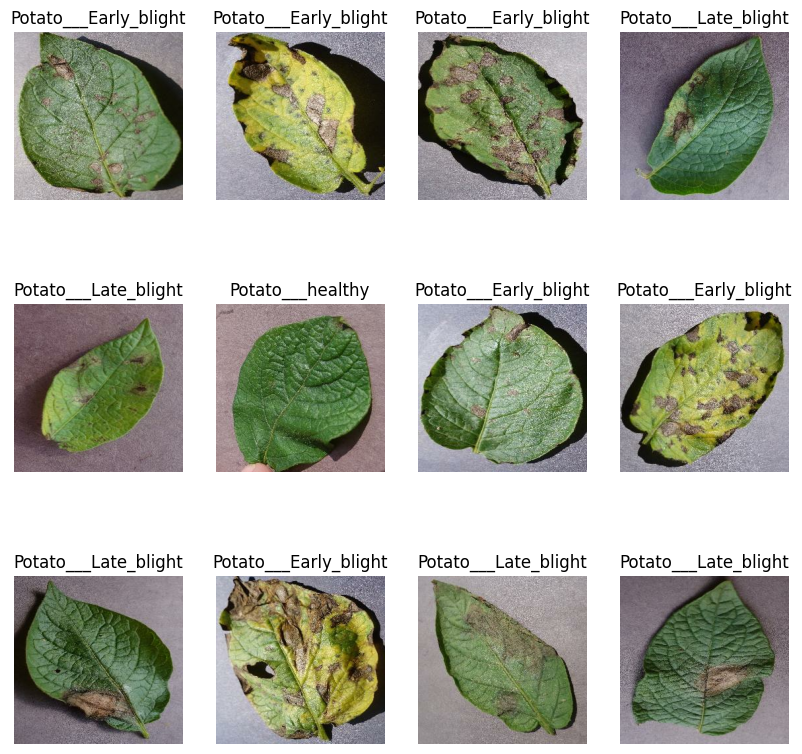

In [ ]:
 plt.figure(figsize = (10,10))
for image_batch, label_batch, in dataset.take (1):
    for i in range (12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [ ]:
len(dataset)

68

In [ ]:
train_size = 0.8   # 80% for training
val_size = 0.2     # 20% for validation


In [ ]:
train_size = 0.8
len(dataset) * train_size

54.400000000000006

In [ ]:
train_ds = dataset.take(54)
len(train_ds)

54

In [ ]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [ ]:
val_size = 0.1
len(dataset) * val_size

6.800000000000001

In [ ]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [ ]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [16]:
def get_dataset_partitions_tf(ds, train_split = 0.8, val_split = 0.1, test_split = 0.1, shuffle = True, shuffle_size = 10000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)

    vals_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return (train_ds, vals_ds, test_ds)


In [17]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [ ]:
len(train_ds)

54

In [ ]:
len(val_ds)

6

In [ ]:
len(test_ds)

8

In [18]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [10]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0/255)
])

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
])
    

In [12]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))


In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 256, 256, 3)       0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

In [19]:
model.compile(
    optimizer = 'adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['Accuracy']
)

In [20]:
history = model.fit(
    train_ds,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    verbose = 1,
    validation_data = val_ds,
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - Accuracy: 0.4844 - loss: 0.8727 - val_Accuracy: 0.6615 - val_loss: 0.7113
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - Accuracy: 0.6539 - loss: 0.7400 - val_Accuracy: 0.7292 - val_loss: 0.6231
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - Accuracy: 0.7691 - loss: 0.5474 - val_Accuracy: 0.8438 - val_loss: 0.4731
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - Accuracy: 0.8628 - loss: 0.3482 - val_Accuracy: 0.9323 - val_loss: 0.2012
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - Accuracy: 0.8733 - loss: 0.3186 - val_Accuracy: 0.9062 - val_loss: 0.2110
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - Accuracy: 0.9115 - loss: 0.2165 - val_Accuracy: 0.9479 - val_loss: 0.1522
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - Accuracy: 0.9178 - loss: 0.2239 - val_Accuracy: 0.9479 - val_loss: 0.1304
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - Accuracy: 0.9421 - loss: 0.1527 - val_Accuracy: 0.9635 - v

In [ ]:
scores = model.evaluate(test_ds)

8/8 [==============================] - 5s 671ms/step - loss: 0.0221 - Accuracy: 0.9922


In [ ]:
scores

[0.022075194865465164, 0.9921875]

In [ ]:
history


In [ ]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [ ]:
history.history.keys()

dict_keys(['loss', 'Accuracy', 'val_loss', 'val_Accuracy'])

In [ ]:
len(history.history['Accuracy'])

50

In [ ]:
acc = history.history['Accuracy']
val_acc = history.history['val_Accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']



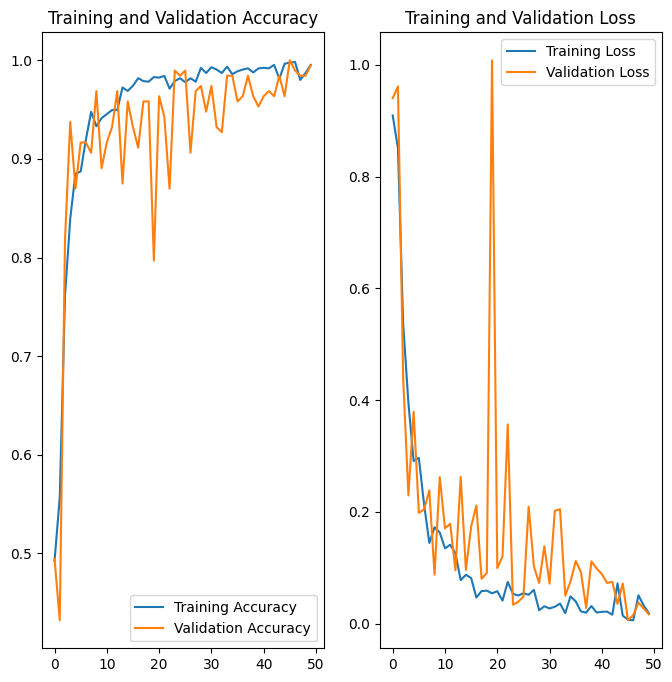

In [ ]:
plt.figure(figsize=(8,8))

# First subplot: Training accuracy
plt.subplot(1,2,1)   # 1 row, 2 columns, first plot
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


# Second subplot: Loss
plt.subplot(1,2,2)   # 1 row, 2 columns, second plot
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()



first image to predict
First image's actual label: Potato___Late_blight
1/1 [==============================] - 1s 738ms/step
Predicted Label: Potato___Late_blight


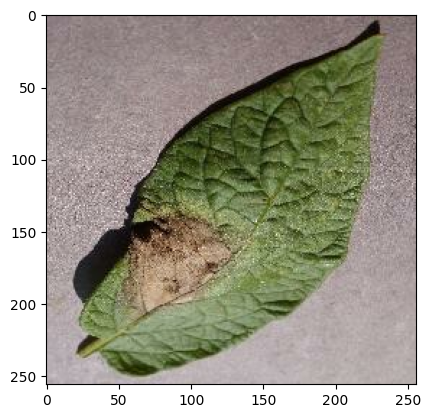

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print('first image to predict')
    plt.imshow(first_image)
    print("First image's actual label:", class_names[first_label])


    batch_prediction = model.predict(images_batch)
    print('Predicted Label:', class_names[np.argmax(batch_prediction [0])])
    
    


In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # create a batch

    predictions = model.predict(img_array)  # <-- use the model instance
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)

    return predicted_class, confidence


1/1 [==============================] - 0s 58ms/step


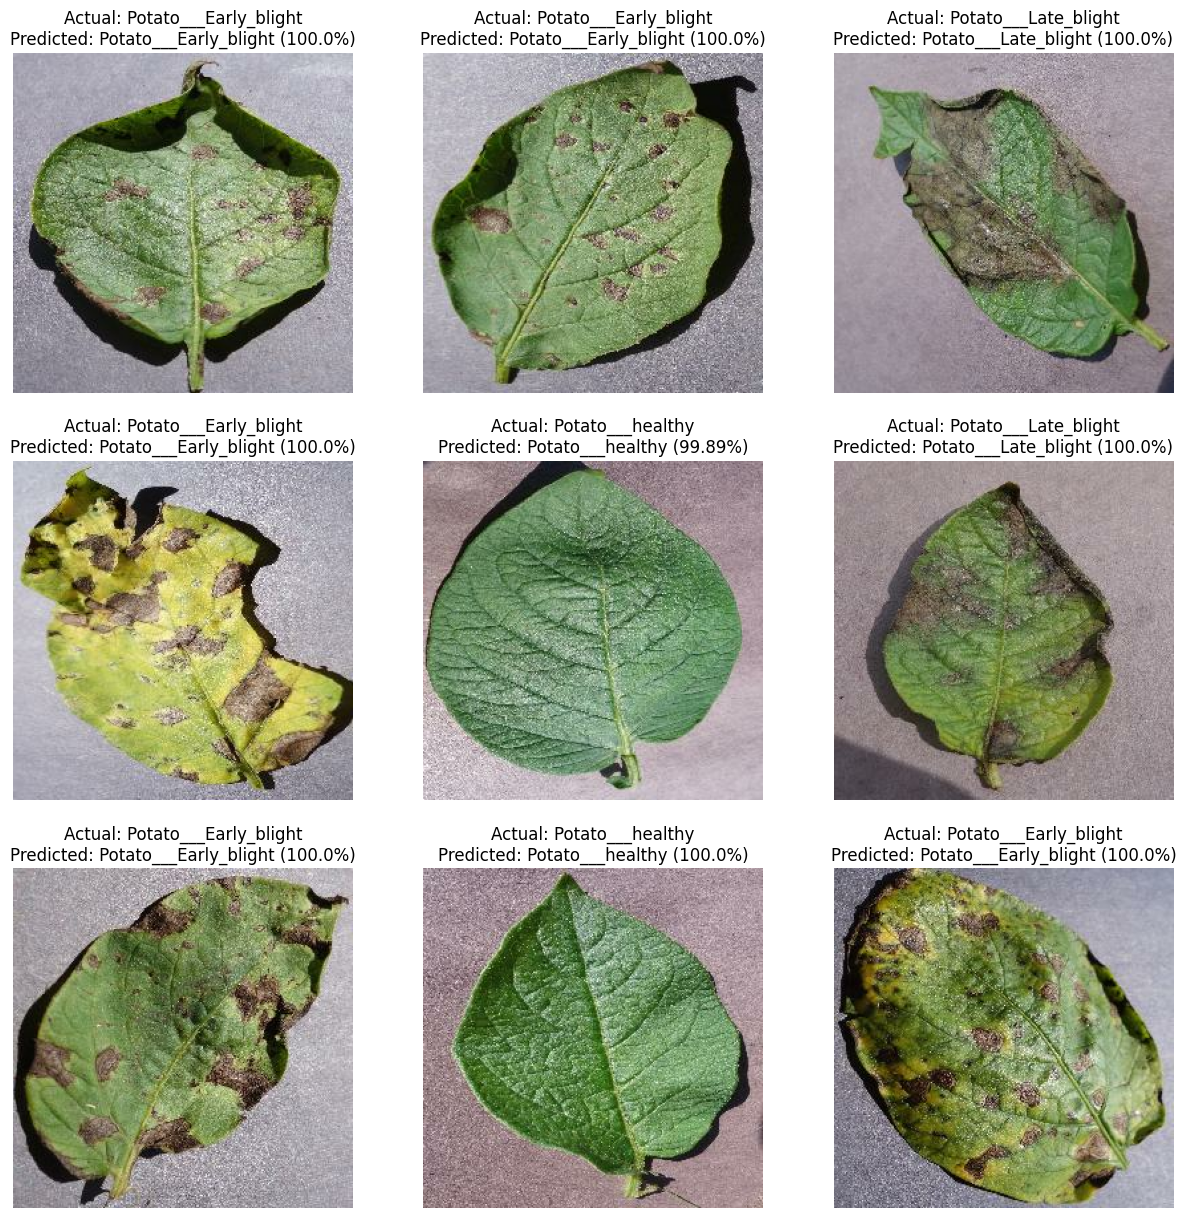

In [ ]:
import numpy as np
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f'Actual: {actual_class}\nPredicted: {predicted_class} ({confidence}%)')
        plt.axis('off')


In [ ]:
model_version = 1
model.save(f'../models/{model_version}.keras')   # recommended format


In [ ]:
model_version = 2
model.save(f'../models/{model_version}.keras')   # recommended format


In [ ]:
[int(os.path.splitext(i)[0]) for i in os.listdir("../models") if i.endswith(".keras")] #Convert to integer 


[1, 2]

In [ ]:
[int(os.path.splitext(i)[0]) for i in os.listdir("../models") if i.endswith(".keras")] + [0] #Model 0 as version


[1, 2, 0]

In [ ]:
max([int(os.path.splitext(i)[0]) for i in os.listdir("../models") if i.endswith(".keras")] + [0]) + 1 #Max model version


3

In [3]:
import os
model_version = max([int(os.path.splitext(i)[0]) for i in os.listdir("../models") if i.endswith(".keras")] + [0]) + 1 #Max model version
model.save(f'../models/{model_version}.keras')

NameError: name 'model' is not defined

In [ ]:
from tensorflow import keras
model = keras.models.load_model('../models/1.keras')


In [21]:
model.save('models/potato_disease_model.keras')